In [1]:
# Import libraries
import fastcore.all as fca
import fastai.vision.all as fva

In [2]:
# Define path to the image data
path = 'data/'

In [3]:
# Create fastai data block to ingest the training and validation images
farm_animals = fva.DataBlock(
    blocks=(fva.ImageBlock, fva.CategoryBlock), 
    get_items=fva.get_image_files, 
    splitter=fva.RandomSplitter(valid_pct=0.2, seed=42),
    get_y=fva.parent_label,
    item_tfms=fva.Resize(128)
)

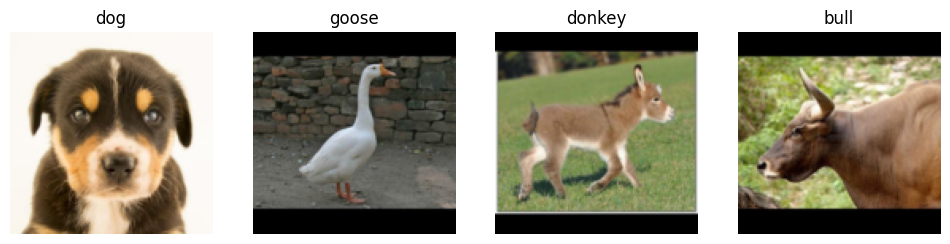

In [4]:
# Create data loaders and display several images
dls = farm_animals.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

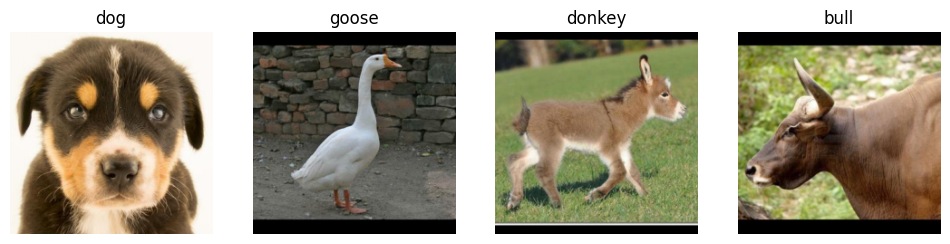

In [5]:
# Randomize cropping of every image and augment the dataset
farm_animals.new(
    item_tfms=fva.RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=fva.aug_transforms()
)

# Create dataloaders
dls = farm_animals.dataloaders(path)

# Display a couple of images after the transofrmation
dls.valid.show_batch(max_n=4, nrows=1)

In [6]:
# Train initial model
model = fva.vision_learner(dls, fva.resnet18, metrics=fva.error_rate)
model.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,3.039403,0.677256,0.213816,01:41


epoch,train_loss,valid_loss,error_rate,time
0,0.874852,0.542503,0.171053,03:06
1,0.667534,0.553241,0.167763,03:59
2,0.534143,0.487073,0.144737,03:48
3,0.430845,0.479607,0.144737,03:31


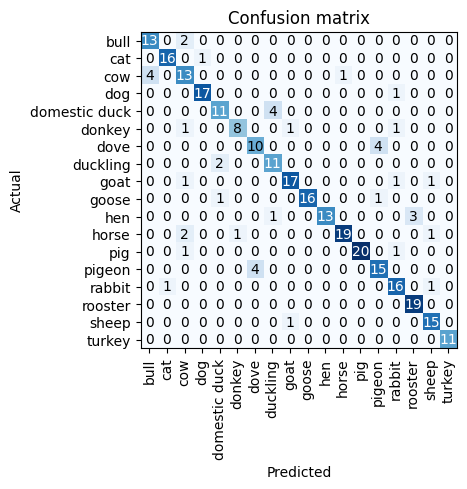

In [7]:
# Evaluate model performance
conf_matrix = fva.ClassificationInterpretation.from_learner(model)
conf_matrix.plot_confusion_matrix()

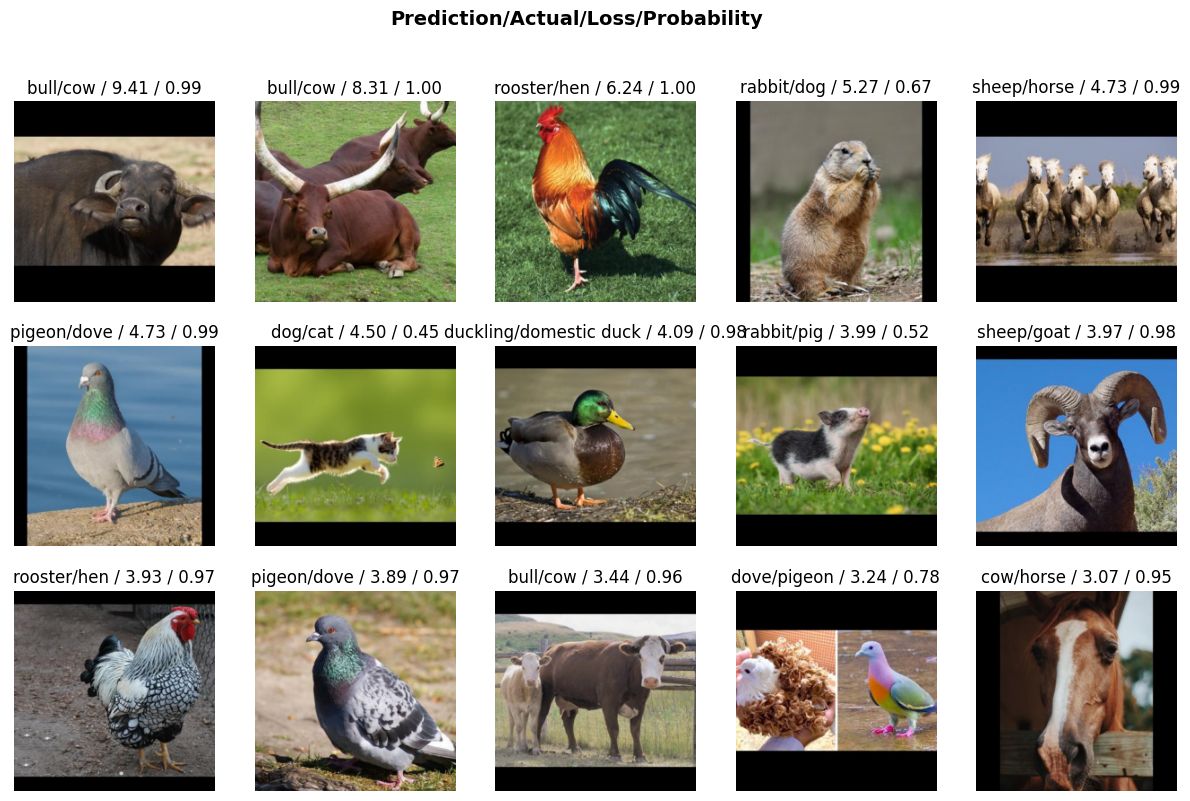

In [8]:
# Display the mistaken predictions
conf_matrix.plot_top_losses(15, nrows=3)